# Polymarket Backtest Explorer

In [1]:
import sys
sys.path.insert(0, "..")

import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

import backtest as bt
import pandas as pd

## Compare all signals

always_long           PnL=$  254.50  Sharpe=3.00
always_short          PnL=$ -254.50  Sharpe=-3.00
mean_reversion        PnL=$  -97.85  Sharpe=-3.04
momentum              PnL=$  176.30  Sharpe=2.19
threshold             PnL=$   95.30  Sharpe=2.95
fade                  PnL=$   15.86  Sharpe=1.18

Signal                      PnL   Sharpe      MaxDD   WinRate  Markets
----------------------------------------------------------------------
always_long          $   254.50     3.00 $   -49.30    22.2%       27
momentum             $   176.30     2.19 $   -68.05    26.1%       23
threshold            $    95.30     2.95 $   -18.15     8.0%       25
fade                 $    15.86     1.18 $   -23.41    29.6%       27
mean_reversion       $   -97.85    -3.04 $  -116.35    60.9%       23
always_short         $  -254.50    -3.00 $  -278.55    44.4%       27


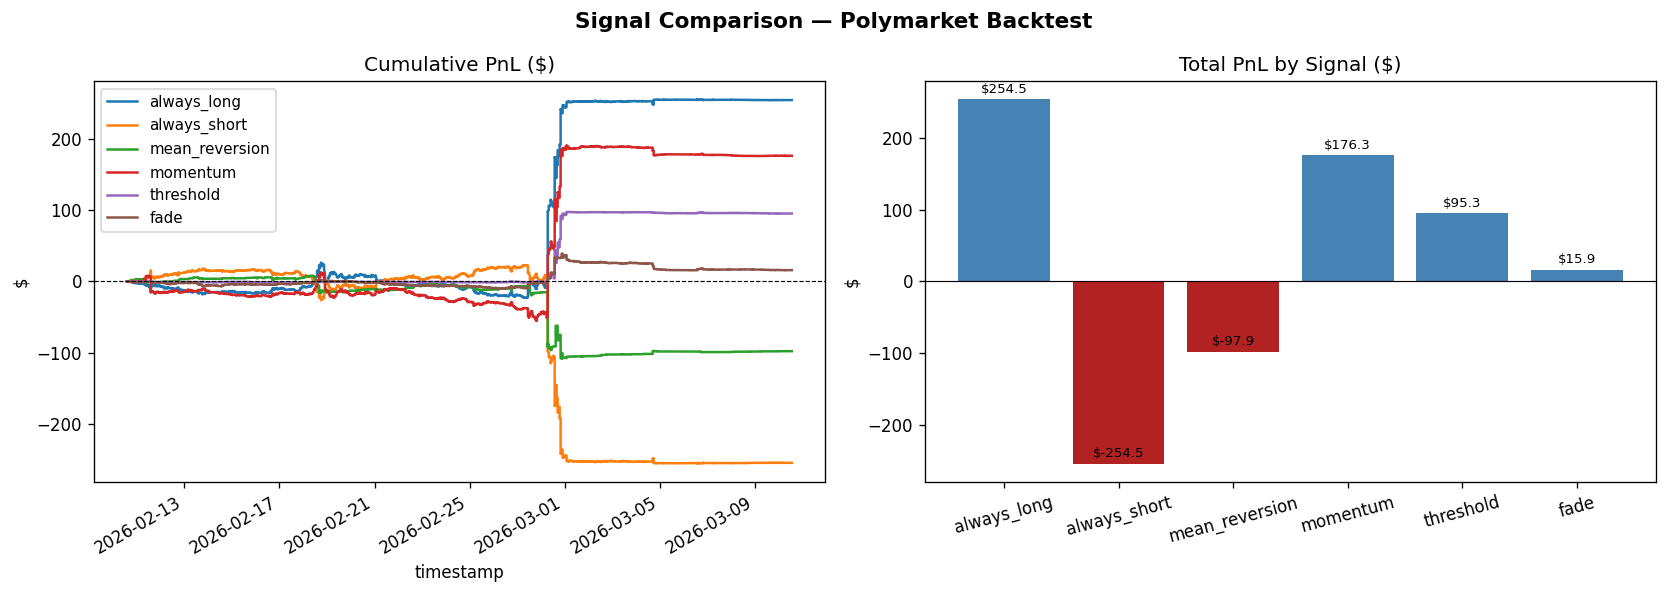

In [2]:
results = []
for name, sig in bt.ALL_SIGNALS.items():
    r = bt.run(sig, notional=100.0)
    results.append(r)
    print(f"{name:<20}  PnL=${r.stats['total_pnl']:>8.2f}  Sharpe={r.stats['sharpe']:.2f}")

fig = bt.plot_compare(results)

## Drill into a single signal

/Users/admin/polypheme/backtest.py:459: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


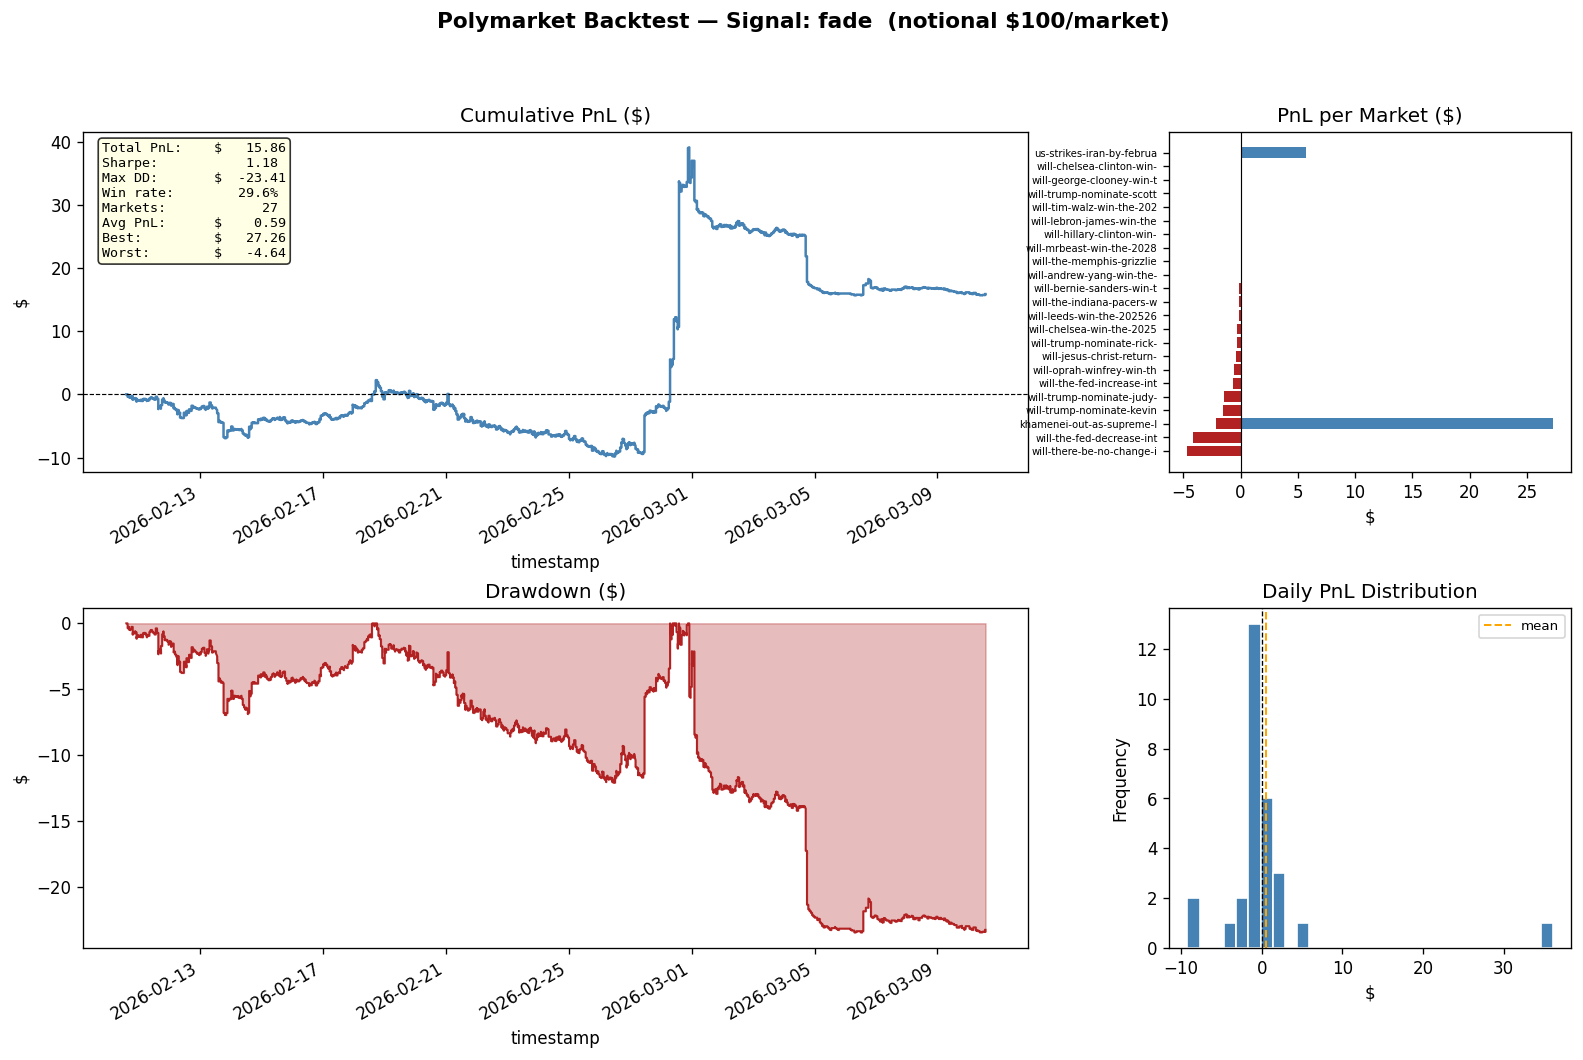

In [3]:
SIGNAL = "fade"   # change to: always_long, always_short, mean_reversion, momentum, threshold, fade

r = bt.run(bt.ALL_SIGNALS[SIGNAL], notional=100.0)
fig = bt.plot(r)

## Intraday data (1-minute bars)

/Users/admin/polypheme/backtest.py:459: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


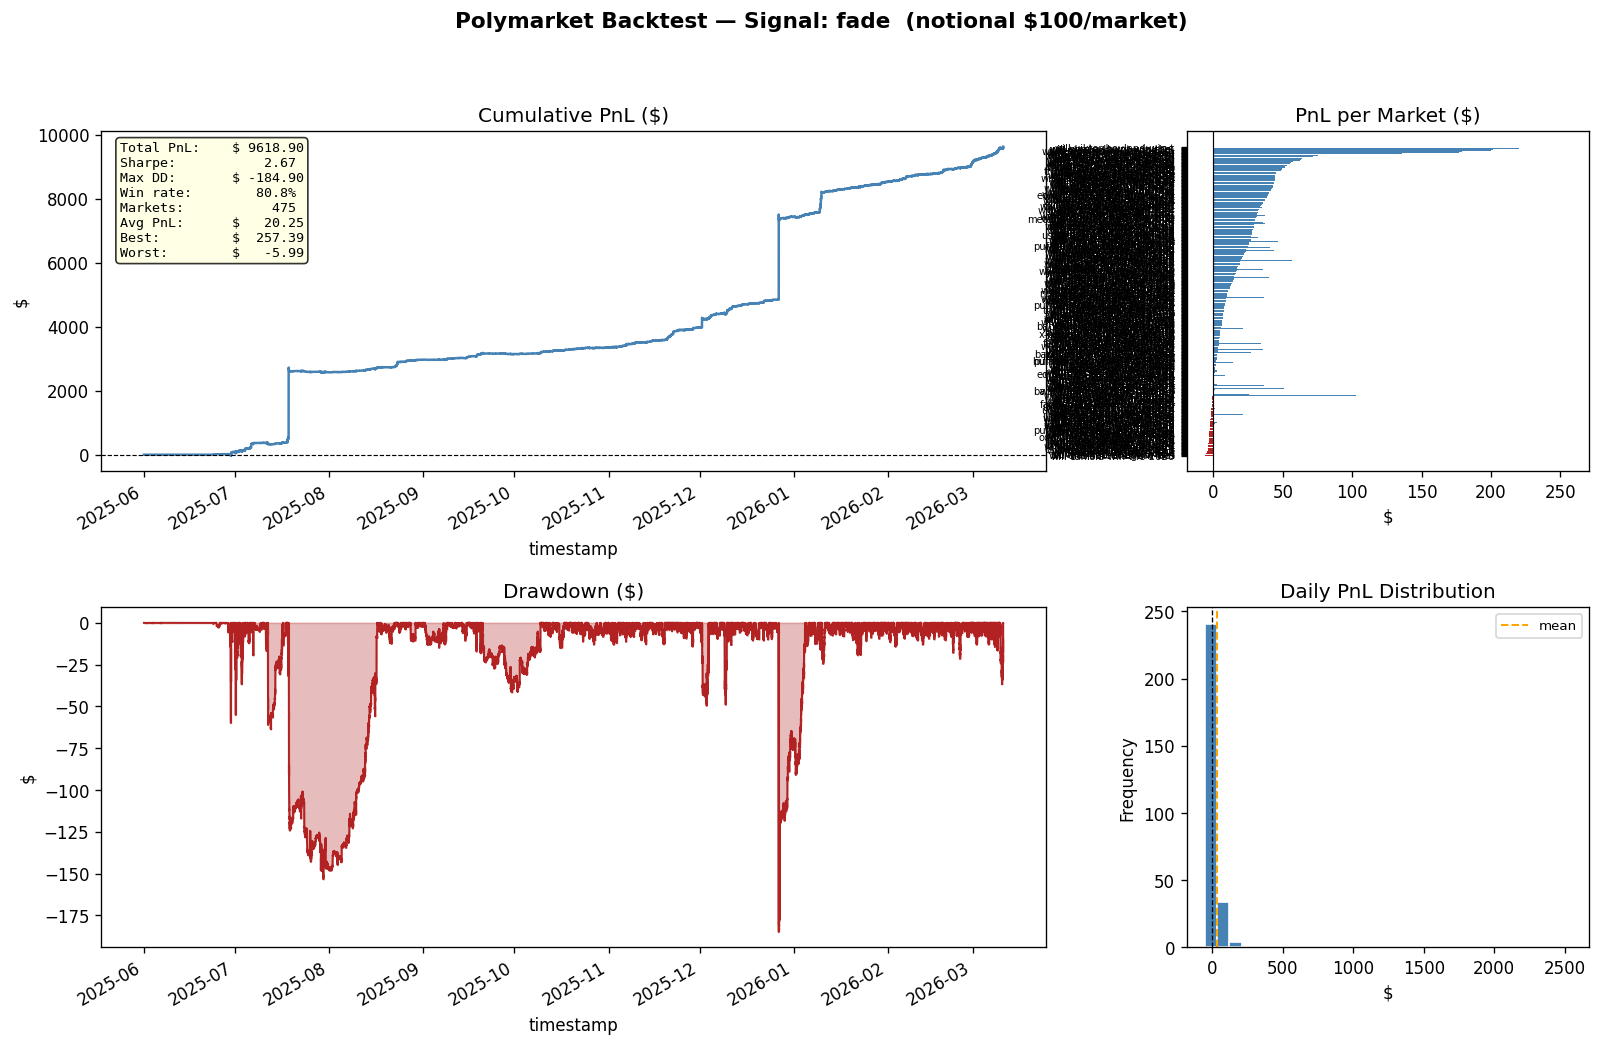

In [4]:
r_intraday = bt.run(
    bt.ALL_SIGNALS["fade"],
    notional=100.0,
    prices_path="data/intraday_1m.parquet",
)
fig = bt.plot(r_intraday)

## Custom signal — try your own

/Users/admin/polypheme/backtest.py:459: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


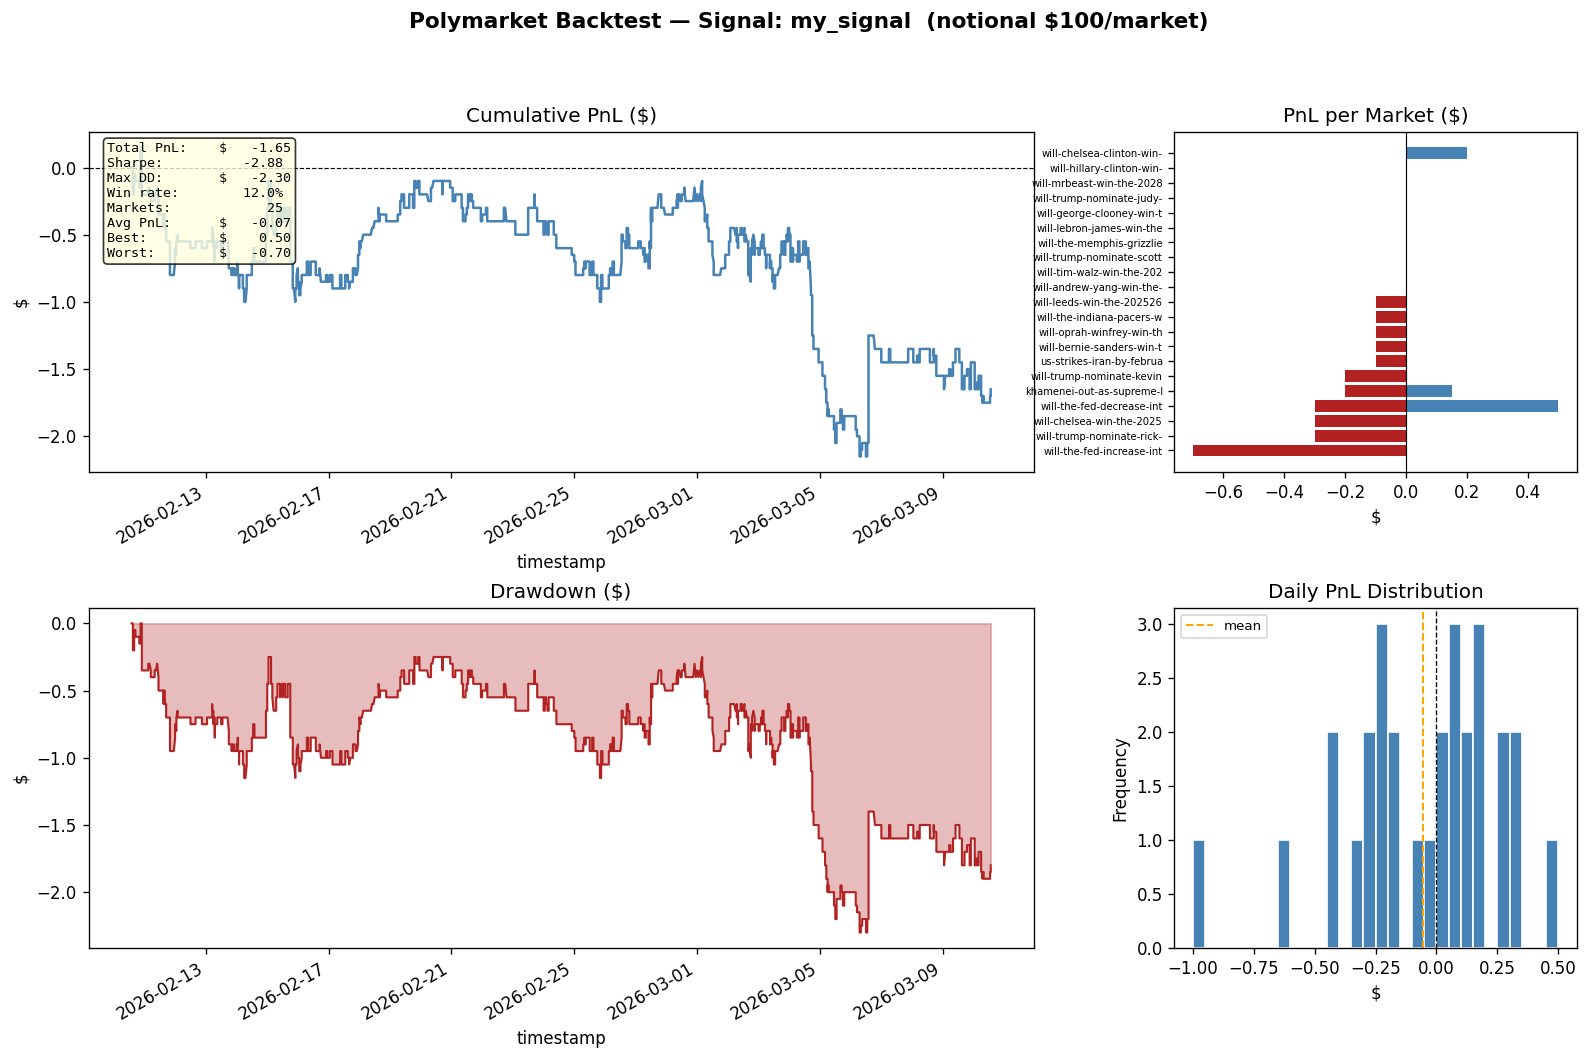

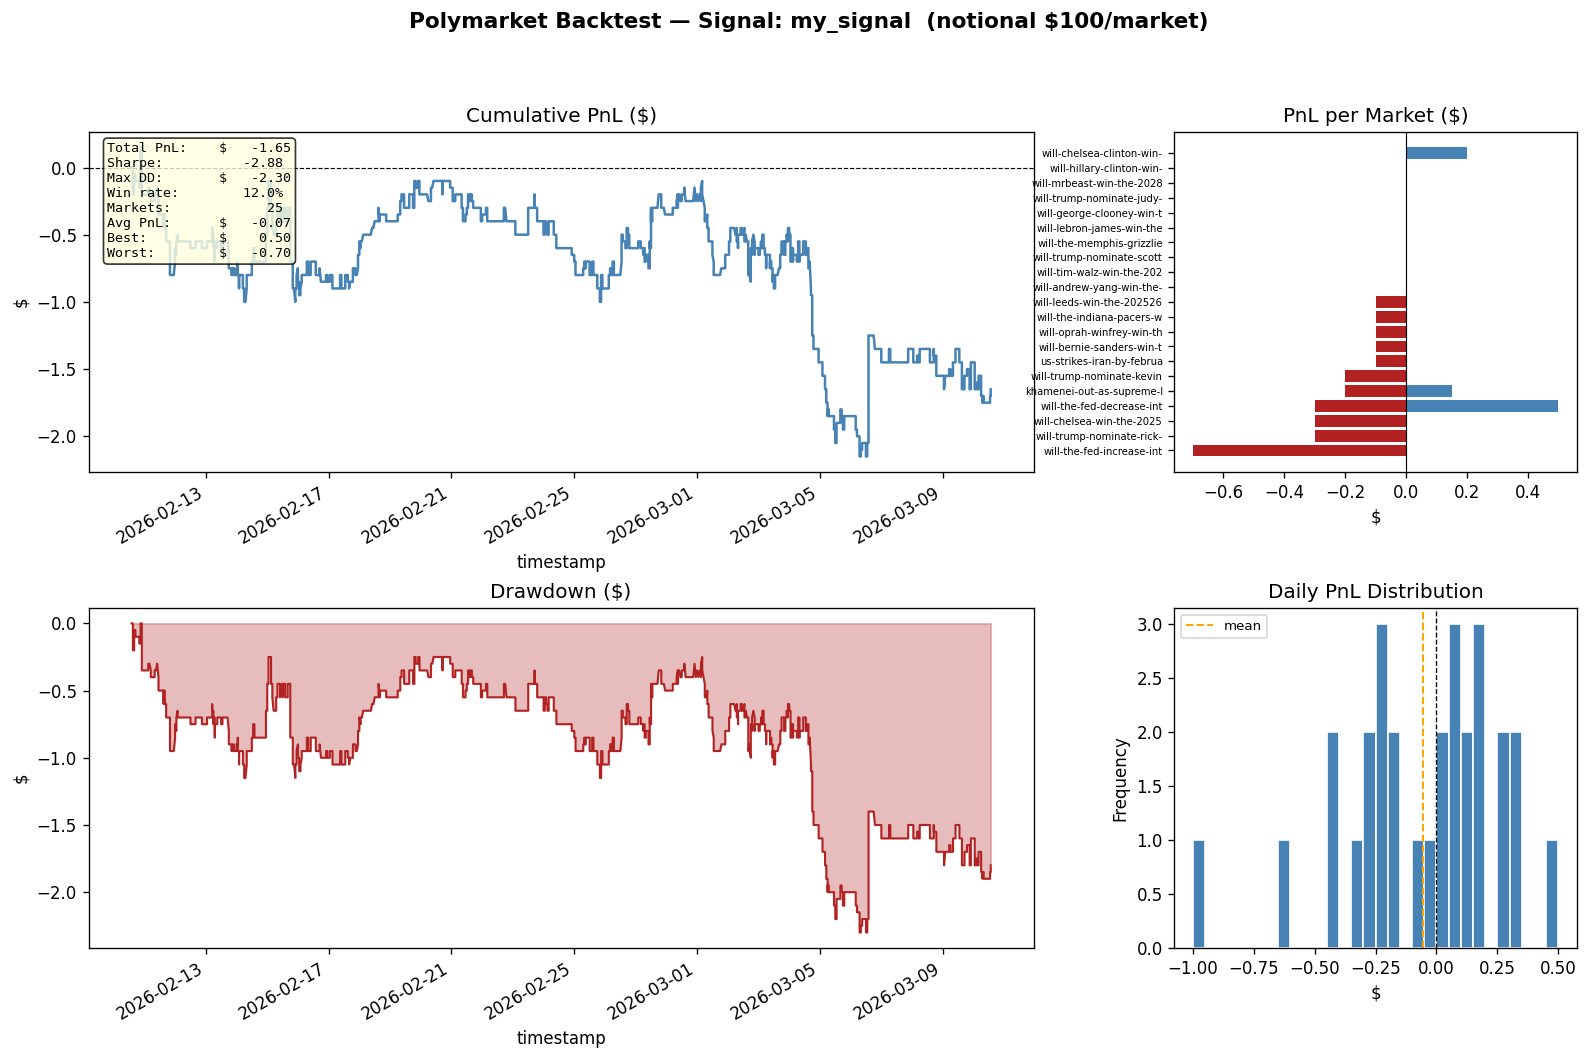

In [6]:
import numpy as np

class MySignal(bt.Signal):
    name = "my_signal"

    def generate(self, history):
        prices = history.set_index("timestamp")["price"]
        signal = pd.Series(0.0, index=prices.index)
        signal[prices < 0.01] = 1.0   # buy very cheap
        signal[prices > 0.99] = -1.0  # sell very expensive
        return signal

r_custom = bt.run(MySignal(), notional=100.0)
bt.plot(r_custom)